<div align="center">

# Machine Learning
## Regresión Polinomica
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 29 Febrero 2026

<br><br><br><br><br><br><br><br><br><br>

---

## **Resumen**
<p style="text-align: justify">Este documento contiene el desarrollo de ejercicios prácticos de machine learning y regresión polinomica, incluyendo representaciones gráficas mediante graficos de dispersión con operaciones sobre modelo de entrenamiento y error cuadratico medio. Se carga dataset mencionados en clase.

</div>

## Librerias

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt

import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

import seaborn as sns 

## Datos

### Transformación de datos
1. Establecer campos traducidos
2. Obtenemos datos especificos para el modelo
3. Mostramos Datos iniciales

In [12]:
data = pd.read_csv("../Bases/energia_temperatura.csv")
data.isnull().sum()
data.head(5)

,temperatura_C,consumo_kWh
0,-10.000000,587.450712
1,-9.748744,568.931313
2,-9.497487,571.826891
3,-9.246231,576.164303
4,-8.994975,541.114855


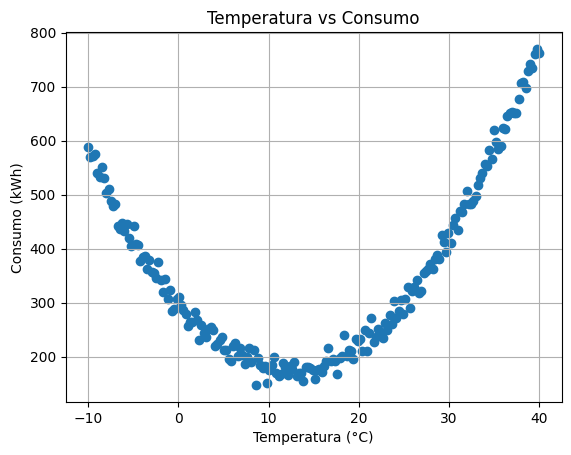

In [13]:
x = data["temperatura_C"]
y = data["consumo_kWh"]

x_Array = np.array(x).reshape(-1,1)
y_Array = np.array(y)

plt.scatter(x_Array,y_Array)
plt.title("Temperatura vs Consumo")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Consumo (kWh)")
plt.grid()
plt.show()

## Entrenamiento - Metodo Lineal

### Modelo de prediccion
1. Se establecen datos para el entrenamiento del modelo
2. Se entrena el modelo con los datos para realizar la regresión lineal
3. obtenemos los parametros de acuerdo a lo estudiado en el modelo.
4. Imprimimos los datos importantes para tener los datos proyectados

In [20]:
modelo = LinearRegression()
modelo.fit(x_Array,y_Array)
predict_y = modelo.predict(x_Array)

b = modelo.intercept_
m = modelo.coef_[0]

y_pred = modelo.predict(x_Array)

r2 = r2_score(y_Array,predict_y)
recm =  mean_squared_error(y_Array, predict_y)**(1/2)

print(f"r2: {r2}")
print(f"ercm: {recm}")

print(f"Pendiente: {m}")
print(f"Punto de corte: {b}")

print(f"Y = {m} X + ({b})")

r2: 0.13267914501512224
ercm: 150.89099554729435
Pendiente: 4.068402285543133
Punto de corte: 286.7041097819853
Y = 4.068402285543133 X + (286.7041097819853)


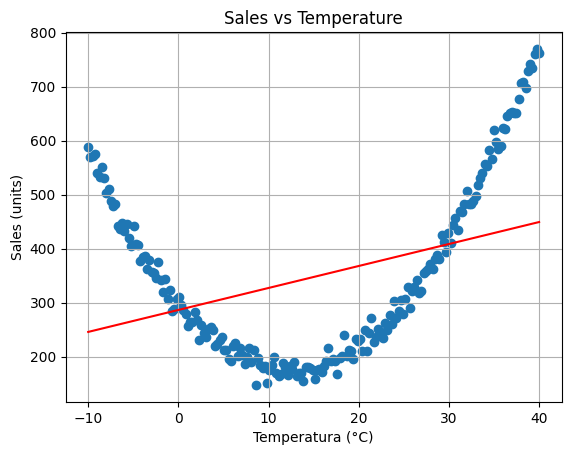

In [ ]:
plt.scatter(x_Array,y_Array)
plt.plot(x,y_pred, color="red")
plt.title("Sales vs Temperature")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Sales (units)")
plt.grid()
plt.show()

<p style="text-align: justify">En este caso este modelo no funciona porque no predice ningun valor inportante en el historico de datos obtenidos, es por ello que es importante emplear otro modelo que nos permita identificar de manera clara el patron de relación de estos datos, para ello en este espacio revisaremos el modelo polinomial.</p>

## Entrenamiento - Metodo Polinomial

In [ ]:
modelo_p = PolynomialFeatures(degree=2)
x_modelo_p = modelo_p.fit_transform(x_Array)

#Entrenamos el modelo Lineal con los datos entrenados del Modelo polinomial
modelo_L = LinearRegression()
modelo_L.fit(x_modelo_p,y_Array)
predict_y_P = modelo_L.predict(x_modelo_p)

r2 = r2_score(y_Array,predict_y_P)
recm =  mean_squared_error(y_Array, predict_y_P)**(1/2)

b = modelo_L.intercept_
m = modelo_L.coef_

print(f"r2: {r2}")
print(f"ercm: {recm}")
print(f"Pendiente: {m}")
print(f"Punto de corte: {b}")
print(f"Y = {m} X + ({b})")

r2: 0.9926492539031974
ercm: 13.891180045302452
Pendiente: [  0.         -19.88161946   0.79833406]
Punto de corte: 298.3381236942764
Y = [  0.         -19.88161946   0.79833406] X + (298.3381236942764)


### Grafica del entrenamiento polinomial

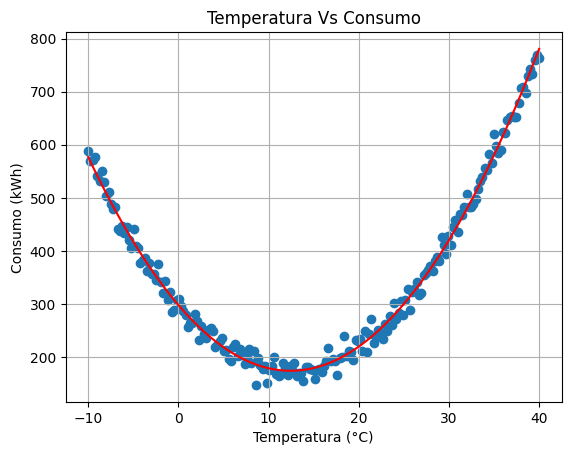

In [28]:
plt.scatter(x_Array,y_Array)
plt.plot(x,predict_y_P, color="red")
plt.title("Temperatura Vs Consumo")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Consumo (kWh)")
plt.grid()
plt.show()